# Shape and pull together

Notebooks 12 and 13 relaxed the two assumptions separately, and found them to behave in
opposite ways.

|  | changes the board? | cost of ignoring it | cost to compute |
|---|---|---|---|
| **shape** ($\Sigma$ not round) | yes -- doubles swing by 1.4x | 0.14 visits/leg | one MDP solve per covariance |
| **pull** ($b \neq 0$) | no -- the game is translated | 0.91 visits/leg | none: actions are relabelled |

Because bias needs no solves of its own, a joint model costs exactly what the shape model
costs on its own. That is what makes this third experiment worth running rather than merely
imagining.

Which leaves the question the separate experiments could not answer: **do the two
interact?** Three ways they might.

1. **Do the costs add?** If ignoring the shape costs 0.14 and ignoring the pull 0.91, does
   ignoring both cost 1.05, or does one mask the other?
2. **Does the shape decide which pull hurts?** A tall thrower is already spraying vertically.
   A vertical pull might disappear into that noise, while a horizontal pull -- in the
   direction they are *precise* -- could be far more damaging. If so, "how bad is your pull"
   has no answer without knowing the shape.
3. **Is the joint model still identifiable?** Four numbers from scores alone, with no
   coordinates, is a lot to ask.

In [1]:
import os
import sys
import time
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.dartboards import generate_dartboard
from darts.throw_shape import (ShapeRecommender, ThrowPosterior, bias_grid,
                               bias_prior, isotropic_equivalent, play_leg,
                               shape_prior, sigma_matrices)
from darts.utils import aim_description, mm_per_pixel

PX = 256
BOARD, CHECKOUTS = generate_dartboard(PX)
MM = mm_per_pixel(PX)
CENTRE = PX // 2

TALL = np.array([[12.0 ** 2, 0.0], [0.0, 20.0 ** 2]])     # tall, narrow group
ROUND = isotropic_equivalent(TALL) ** 2 * np.eye(2)
PULL = np.array([4.0, -9.0])                              # right and low
N_LEGS = 200

SX = SY = np.array([8.0, 12.0, 16.0, 20.0, 24.0])
SIGMAS, _ = sigma_matrices(SX, SY)
t0 = time.perf_counter()
rec = ShapeRecommender(SIGMAS, board_pixels=PX, point_stride=2)
print(f'{len(rec.models)} MDPs solved in {time.perf_counter()-t0:.0f}s')
print('the bias axis adds no solves at all -- actions are relabelled')

25 MDPs solved in 128s
the bias axis adds no solves at all -- actions are relabelled


## 1. Do the two mistakes add?

The player below is genuinely tall *and* pulls. Four models are asked to advise them: right
about both, right about one, right about neither. Everything is scored the same way -- the
expected visits lost per leg against a model that knows the truth.

In [2]:
combos = {
    'knows both': (TALL, PULL),
    'knows the shape, misses the pull': (TALL, np.zeros(2)),
    'knows the pull, thinks round': (ROUND, PULL),
    'knows neither': (ROUND, np.zeros(2)),
}
rows = []
for name, belief in combos.items():
    rng = np.random.default_rng(77)
    post = ThrowPosterior(rec.Sigmas, board=rec.board, checkouts=rec.checkouts)
    visits, lost = [], []
    for _ in range(N_LEGS):
        log = []
        play_leg(rec, post, TALL, PULL, rng, policy=belief, record=log)
        df = pd.DataFrame(log)
        visits.append(int((df.state_dart == 1).sum()))
        lost.append(df.value_loss.sum())
    visits, lost = np.array(visits), np.array(lost)
    rows.append({'model believes': name,
                 'visits lost per leg': lost.mean(),
                 '+/-': lost.std(ddof=1) / np.sqrt(N_LEGS),
                 'realised visits': visits.mean()})
grid2x2 = pd.DataFrame(rows).set_index('model believes')
shape_only = grid2x2.loc['knows the pull, thinks round', 'visits lost per leg']
pull_only = grid2x2.loc['knows the shape, misses the pull', 'visits lost per leg']
both = grid2x2.loc['knows neither', 'visits lost per leg']
print(f'ignoring the shape alone : {shape_only:.3f}')
print(f'ignoring the pull alone  : {pull_only:.3f}')
print(f'sum, if independent      : {shape_only + pull_only:.3f}')
print(f'ignoring both, measured  : {both:.3f}   '
      f'({100*(both/(shape_only+pull_only)-1):+.0f}% vs the sum)')
grid2x2.round(3)

ignoring the shape alone : 0.137
ignoring the pull alone  : 0.739
sum, if independent      : 0.876
ignoring both, measured  : 0.788   (-10% vs the sum)


,visits lost per leg,+/-,realised visits
model believes,,,
knows both,0.000,0.000,9.535
"knows the shape, misses the pull",0.739,0.022,10.080
"knows the pull, thinks round",0.137,0.006,9.645
knows neither,0.788,0.022,10.260


The two mistakes are **mildly sub-additive**: 0.137 for the shape alone, 0.739 for the pull
alone, and 0.788 for both together against a sum of 0.876 -- about 10% less than independent
errors would predict, and comfortably outside the Monte Carlo error.

So they do not compound; if anything each slightly masks the other, which makes sense once
you notice that both mistakes push the recommended aim point around and their displacements
need not agree in direction. The practical reading is reassuring: a model that fixes only
one of the two still collects nearly all of that one's benefit.

The ordering is the same as in the separate notebooks and the magnitudes are the same to
within a rounding: **the pull dominates the shape by roughly five to one.** If you can only
model one thing about a player beyond their overall spread, model where they pull.

One detail worth flagging, because it corroborates the next section: ignoring this pull
costs the *tall* player 0.739 visits, while notebook 13 measured 0.913 for the same pull on
a *round* player. The pull is mostly vertical, and the tall player is comparatively immune
to vertical error. That difference is the interaction, and the next section isolates it.

## 2. Does the shape decide which pull hurts?

The sharper question. Take the same tall thrower and give them a pull of the same size, once
vertically -- along the axis they already spray -- and once horizontally, along the axis they
are precise. Then do the same for a *round* thrower, where by symmetry the direction should
not matter at all.

If the shape decides which pull hurts, the tall player's two rows will differ and the round
player's will not.

In [3]:
MAG = 10.0
rows = []
for player_name, S in [('tall (12, 20)', TALL), ('round (16.5)', ROUND)]:
    for dir_name, b in [('pulls sideways', np.array([MAG, 0.0])),
                        ('pulls vertically', np.array([0.0, -MAG]))]:
        rng = np.random.default_rng(88)
        post = ThrowPosterior(rec.Sigmas, board=rec.board, checkouts=rec.checkouts)
        lost = []
        for _ in range(N_LEGS):
            log = []
            play_leg(rec, post, S, b, rng, policy=(S, np.zeros(2)), record=log)
            lost.append(pd.DataFrame(log).value_loss.sum())
        lost = np.array(lost)
        rows.append({'player': player_name, 'pull': dir_name,
                     'visits lost by ignoring it': lost.mean(),
                     '+/-': lost.std(ddof=1) / np.sqrt(N_LEGS)})
direction = pd.DataFrame(rows)
direction.pivot(index='player', columns='pull',
                values='visits lost by ignoring it').round(3)

pull,pulls sideways,pulls vertically
player,,
round (16.5),1.116,0.815
"tall (12, 20)",1.928,0.482


,player,pull,visits lost by ignoring it,+/-
0,"tall (12, 20)",pulls sideways,1.928,0.038
1,"tall (12, 20)",pulls vertically,0.482,0.017
2,round (16.5),pulls sideways,1.116,0.028
3,round (16.5),pulls vertically,0.815,0.023


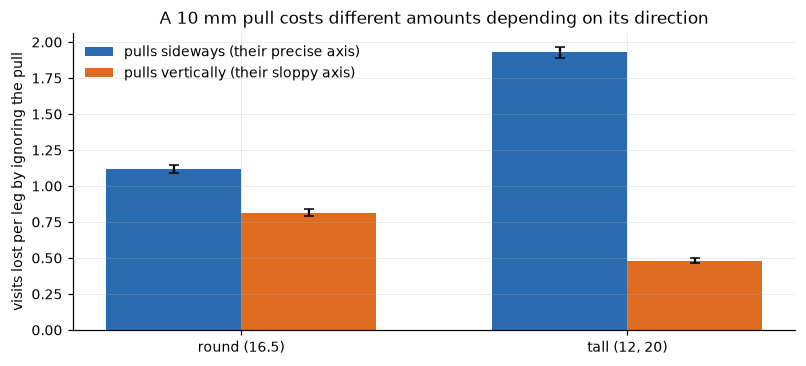

In [4]:
fig, ax = plt.subplots(figsize=(7.4, 3.4))
piv = direction.pivot(index='player', columns='pull', values='visits lost by ignoring it')
err = direction.pivot(index='player', columns='pull', values='+/-')
x = np.arange(len(piv))
w = 0.35
ax.bar(x - w / 2, piv['pulls sideways'], w, yerr=err['pulls sideways'], capsize=3,
       label='pulls sideways (their precise axis)', color='#2b6cb0')
ax.bar(x + w / 2, piv['pulls vertically'], w, yerr=err['pulls vertically'], capsize=3,
       label='pulls vertically (their sloppy axis)', color='#dd6b20')
ax.set_xticks(x); ax.set_xticklabels(piv.index)
ax.set_ylabel('visits lost per leg by ignoring the pull')
ax.set_title(f'A {MAG:.0f} mm pull costs different amounts depending on its direction')
ax.legend()
fig.tight_layout()
direction.round(3)

**The shape decides which pull hurts, and by a factor of four.**

For the tall thrower, ignoring a 10 mm sideways pull costs **1.93 visits per leg**; ignoring
the same 10 mm pull vertically costs **0.48**. A pull along the axis they are precise in is
four times as damaging as the identical pull along the axis they already spray. The
intuition is right: vertical error disappears into a group that is already 20 mm tall, while
horizontal error stands out against a group only 12 mm wide.

The round player is the control, and it is a *useful* control because it does not come out
flat: 1.12 sideways against 0.82 vertically, a ratio of 1.37. The board itself is not
rotationally symmetric -- the scoring beds present different dimensions to radial and
tangential error, and the best targets sit at particular angles -- so some directional
asymmetry exists for everyone. The tall player's ratio of 4.0 is that board effect
*amplified about threefold by the shape of their throw*.

This is the genuine interaction, and it is the answer to a question neither separate
experiment could pose: **"how bad is my pull?" has no answer without knowing the shape of
the group it sits inside.** A coach told only that a player pulls 10 mm cannot say whether
that is worth half a visit a leg or two.

## 3. Can four numbers be learned from scores alone?

The statistical question. The posterior now runs over a grid of covariances *and* a grid of
biases, and has to separate all four from nothing but the numbers a player writes down.

In [5]:
FINE_S, _ = sigma_matrices(np.arange(8.0, 24.1, 2.0), np.arange(8.0, 24.1, 2.0))
FINE_B = bias_grid(np.arange(-12.0, 12.1, 3.0), np.arange(-15.0, 15.1, 3.0))
PRIOR = np.outer(shape_prior(FINE_S, 'league'), bias_prior(FINE_B, sd_mm=10.0))
print(f'joint grid: {len(FINE_S)} covariances x {len(FINE_B)} biases '
      f'= {len(FINE_S)*len(FINE_B)} points')

rng = np.random.default_rng(5)
post = ThrowPosterior(FINE_S, FINE_B, prior=PRIOR, board=rec.board,
                      checkouts=rec.checkouts)
t0 = time.perf_counter()
log = []
for _ in range(30):
    play_leg(rec, post, TALL, PULL, rng, record=log)
hist = pd.DataFrame(log)
sx, sy = post.mean_sigma_xy()
b = post.mean_bias()
print(f'{len(hist)} darts in {time.perf_counter()-t0:.0f}s\n')
pd.DataFrame([
    {'quantity': 'sigma_x', 'truth': 12.0, 'posterior mean': sx},
    {'quantity': 'sigma_y', 'truth': 20.0, 'posterior mean': sy},
    {'quantity': 'ratio', 'truth': 20.0 / 12.0, 'posterior mean': post.mean_ratio()},
    {'quantity': 'bias_x', 'truth': PULL[0], 'posterior mean': b[0]},
    {'quantity': 'bias_y', 'truth': PULL[1], 'posterior mean': b[1]},
]).set_index('quantity').round(2)

joint grid: 81 covariances x 99 biases = 8019 points


805 darts in 886s



,truth,posterior mean
quantity,,
sigma_x,12.00,12.00
sigma_y,20.00,19.23
ratio,1.67,1.60
bias_x,4.00,3.11
bias_y,-9.00,-8.30


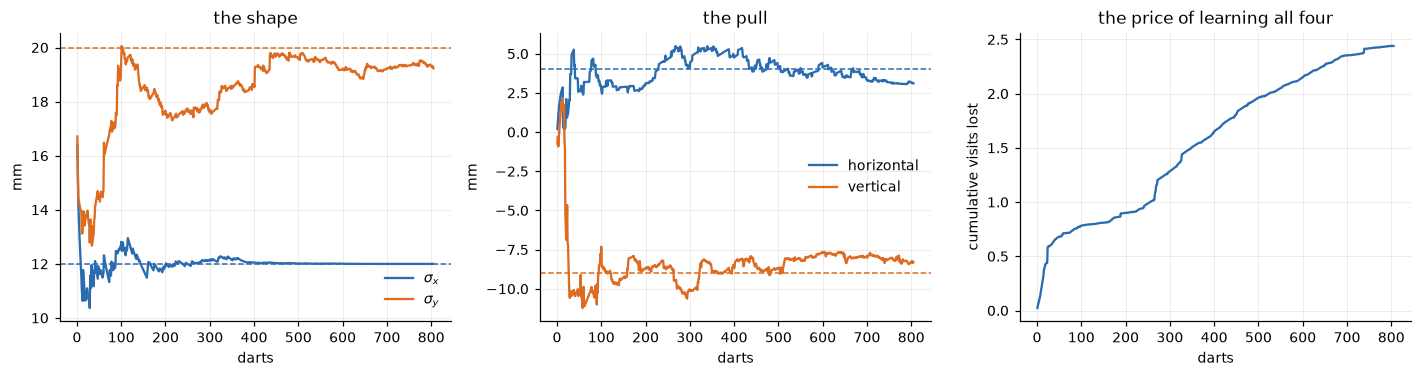

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
x = np.arange(1, len(hist) + 1)
axes[0].plot(x, hist.sigma_x, color='#2b6cb0', label=r'$\sigma_x$')
axes[0].plot(x, hist.sigma_y, color='#dd6b20', label=r'$\sigma_y$')
axes[0].axhline(12.0, color='#2b6cb0', ls='--', lw=1)
axes[0].axhline(20.0, color='#dd6b20', ls='--', lw=1)
axes[0].set_xlabel('darts'); axes[0].set_ylabel('mm'); axes[0].set_title('the shape')
axes[0].legend()

axes[1].plot(x, hist.bias_x, color='#2b6cb0', label='horizontal')
axes[1].plot(x, hist.bias_y, color='#dd6b20', label='vertical')
axes[1].axhline(PULL[0], color='#2b6cb0', ls='--', lw=1)
axes[1].axhline(PULL[1], color='#dd6b20', ls='--', lw=1)
axes[1].set_xlabel('darts'); axes[1].set_ylabel('mm'); axes[1].set_title('the pull')
axes[1].legend()

axes[2].plot(x, hist.value_loss.cumsum(), color='#2b6cb0')
axes[2].set_xlabel('darts'); axes[2].set_ylabel('cumulative visits lost')
axes[2].set_title('the price of learning all four')
fig.tight_layout()

Four numbers, from nothing but the scores, and all four come back:

| | truth | posterior mean |
|---|---|---|
| $\sigma_x$ | 12.0 | 12.00 |
| $\sigma_y$ | 20.0 | 19.23 |
| ratio | 1.67 | 1.60 |
| $b_x$ | +4.0 | +3.11 |
| $b_y$ | −9.0 | −8.30 |

after 805 darts -- about 30 legs, an evening's play. The spread is recovered essentially
exactly, the shape and the pull to within about a millimetre, with both biases pulled
slightly toward zero by the prior, as one would expect at this sample size.

The cumulative-loss curve shows the price of the education: it rises while the model still
believes the player is round and unbiased, then flattens once the posterior has found both.
A one-off payment of a few visits against 0.79 visits per leg, forever, for never learning.

The real constraint here is compute, not statistics. The 8,019-point joint grid took 886
seconds for those 805 darts -- about a second per dart, against 0.4 ms for the
one-dimensional posterior of notebook 11. Profiling splits that second roughly 60/40:
about 390-650 ms to evaluate the likelihood at every grid point (8,019 points times the
~2,000 pixels of the observed score), and about 280 ms to average the Q-values over 25
solved covariances times 99 biases times 8,109 candidate aim points.

The scaling is the plain curse of dimensionality -- a product grid costs
(points per axis) to the power of (parameters):

| parameters | grid points | update |
|---|---|---|
| 1 -- sigma | 55 | 0.43 ms |
| 2 -- sigma_x, sigma_y | 400 | 17 ms |
| 4 -- plus bias | 8,019 | 651 ms |
| 5 -- plus tilt | 40,095 | 1,536 ms |

A second a dart is, honestly, *borderline usable* live -- a real dart is thrown every few
seconds. The problem is that there is no headroom, and the two halves have different cures:
a Laplace approximation or a particle filter fixes the posterior half, but the recommendation
half is a separate sum and only shrinks if the belief is carried on fewer *support points*.
Both are fixed at once by replacing the grid with a small support set -- a few hundred
particles, or the 2d+1 = 9 sigma points of an unscented approximation. (Laplace assumes a
roughly Gaussian posterior; notebook 07 found the single-target posterior can be genuinely
bimodal, and although notebook 13 showed match play breaks that ridge, it is an assumption
that would want checking rather than assuming.)

## Verdict

**Combining the two was worth doing, and the reason is the interaction rather than the
coverage.**

Three findings, in ascending order of how much they change the picture:

1. **The costs are mildly sub-additive** -- 0.79 visits per leg for both mistakes against
   0.88 if they were independent. Modelling one of the two still collects nearly all of its
   benefit, so the work can be done in either order without waste.
2. **The joint model is identifiable.** All four numbers are recovered from about 30 legs of
   ordinary play. The binding constraint is compute -- a second per dart on an 8,019-point
   grid -- not information.
3. **The shape decides which pull hurts, by a factor of four.** For a tall thrower, a
   sideways pull costs 1.93 visits per leg and an identical vertical pull 0.48. The round
   control shows 1.37, so the board contributes some of this and the throw's shape triples
   it.

That third point is the case for the joint model. Separately, the two experiments say "your
shape costs 0.14" and "your pull costs 0.9". Together they say something neither can:
**the same pull is worth anywhere from 0.5 to 1.9 visits a leg depending on which way your
group is stretched.** Advice about a pull is not well-posed without the shape.

### What this leaves

* **Compute.** The grid is the wrong data structure past four parameters. A Laplace
  approximation or a small particle filter would keep this real-time, and would be needed
  before any of it sits behind an app.
* **A tilt.** $\Sigma$ here is axis-aligned. Real throws are plausibly tilted, and
  `sigma_matrices` already accepts a correlation, so it needs no new machinery -- but it is
  not cheap the way bias is. Bias is free precisely because it leaves the board alone;
  a correlation changes $\Sigma$, so it multiplies the **solve** grid as well as the
  posterior grid: 25 solves become 125, and 128 seconds become about 640.
* **Drift.** Everything still assumes the player is constant. A pull is exactly the kind of
  thing that appears when someone tires, so a forgetting factor matters more here than
  anywhere else in this project.
* **A real player.** All of it remains simulated. The Gaussian-with-a-pull model is now rich
  enough to be worth *testing* against a real thrower rather than assumed -- and notebook 13
  showed match play is a strictly better place to fit one than a drill.